# FFB pipeline v4 — depth-only plane-height mask

Tests the fix for the session 2 colour bug (report §10). Session 2's RGB bags were recorded minutes before their depth bags and are not registered to them, so v2's depth ∩ colour mask cuts the bunch. `segment.plane_height_mask` segments from depth alone: pixels more than 3 cm above a RANSAC plane fitted to the tarp.

Sections: 1 setup · 2 recording offsets · 3 masks · 4 volumes and session gap · 5 held-out vs v2 · 6 vs Aqil · 7 threshold sweep · 8 per-bunch predictions · 9 summary.

**Status: exploratory.** Thresholds (3 cm / 3 cm) were fixed before any held-out run, but the bug was found by inspecting this data.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from ffb import io, segment, volume, evaluate as ev, experiment as ex
from ffb.fusion import FusionConfig, fuse

warnings.simplefilter("ignore")
pd.set_option("display.width", 200)
DATA, CACHE, OUT = ROOT / "data", ROOT / "fused_cache", ROOT / "results" / "v4"
OUT.mkdir(parents=True, exist_ok=True)
CFG = FusionConfig(reader="notebook")        # v2's fused depth, reproduced exactly
PRESPECIFIED = dict(h_min=0.03, band=0.03)   # fixed before any held-out run
gt = ex.ground_truth(ROOT)

## 1. Load fused depth (cached)

In [2]:
scenes = {}
for folder in sorted(p for p in DATA.iterdir() if p.is_dir() and p.name.startswith("FFB")):
    b = io.find_bundle(str(folder))
    K = io.intrinsics(b)
    fused, rgb, n = fuse(b, K, CFG, str(CACHE))
    scenes[b.name] = dict(bundle=b, K=K, fused=fused, rgb=rgb, layout=b.layout)
print({k: v["layout"] for k, v in scenes.items()})

{'FFB10': 'combined', 'FFB11': 'combined', 'FFB12': 'combined', 'FFB17': 'combined', 'FFB18': 'combined', 'FFB19': 'combined', 'FFB31': 'split', 'FFB32': 'split', 'FFB33': 'split', 'FFB34': 'split', 'FFB35': 'split'}


## 2. Session 2 depth and RGB were recorded minutes apart
Frame timestamps from each bag. If RGB ends before depth starts, no pairing can align them.

In [3]:
def span(path, stream):
    pipe, _ = io._start(path, [stream]); t = []
    try:
        while True:
            try: fs = pipe.wait_for_frames(timeout_ms=3000)
            except RuntimeError: break
            f = fs.get_depth_frame() if stream == "depth" else fs.get_color_frame()
            if f: t.append(f.get_timestamp() / 1000)
    finally:
        pipe.stop()
    return t[0], t[-1]

rows = []
for name, s in scenes.items():
    b = s["bundle"]
    if b.rgb_bag is None:
        continue
    d0, d1 = span(b.depth_bag, "depth"); c0, c1 = span(b.rgb_bag, "color")
    rows.append(dict(ffb=name, depth_s=round(d1 - d0), rgb_s=round(c1 - c0),
                     rgb_ends_before_depth_starts_s=round(d0 - c1), overlap_s=max(0, round(min(d1, c1) - max(d0, c0)))))
offsets = pd.DataFrame(rows).set_index("ffb"); offsets.to_csv(OUT / "recording_offsets.csv"); offsets

,depth_s,rgb_s,rgb_ends_before_depth_starts_s,overlap_s
ffb,,,,
FFB31,44,38,71,0
FFB32,45,41,35,0
FFB33,50,44,82,0
FFB34,65,56,92,0
FFB35,90,62,43,0


## 3. Masks: v2 (magenta) vs depth-only (green)
In session 2 the v2 mask follows the unregistered colour and cuts into the depth blob; in session 1 (aligned depth) both agree.

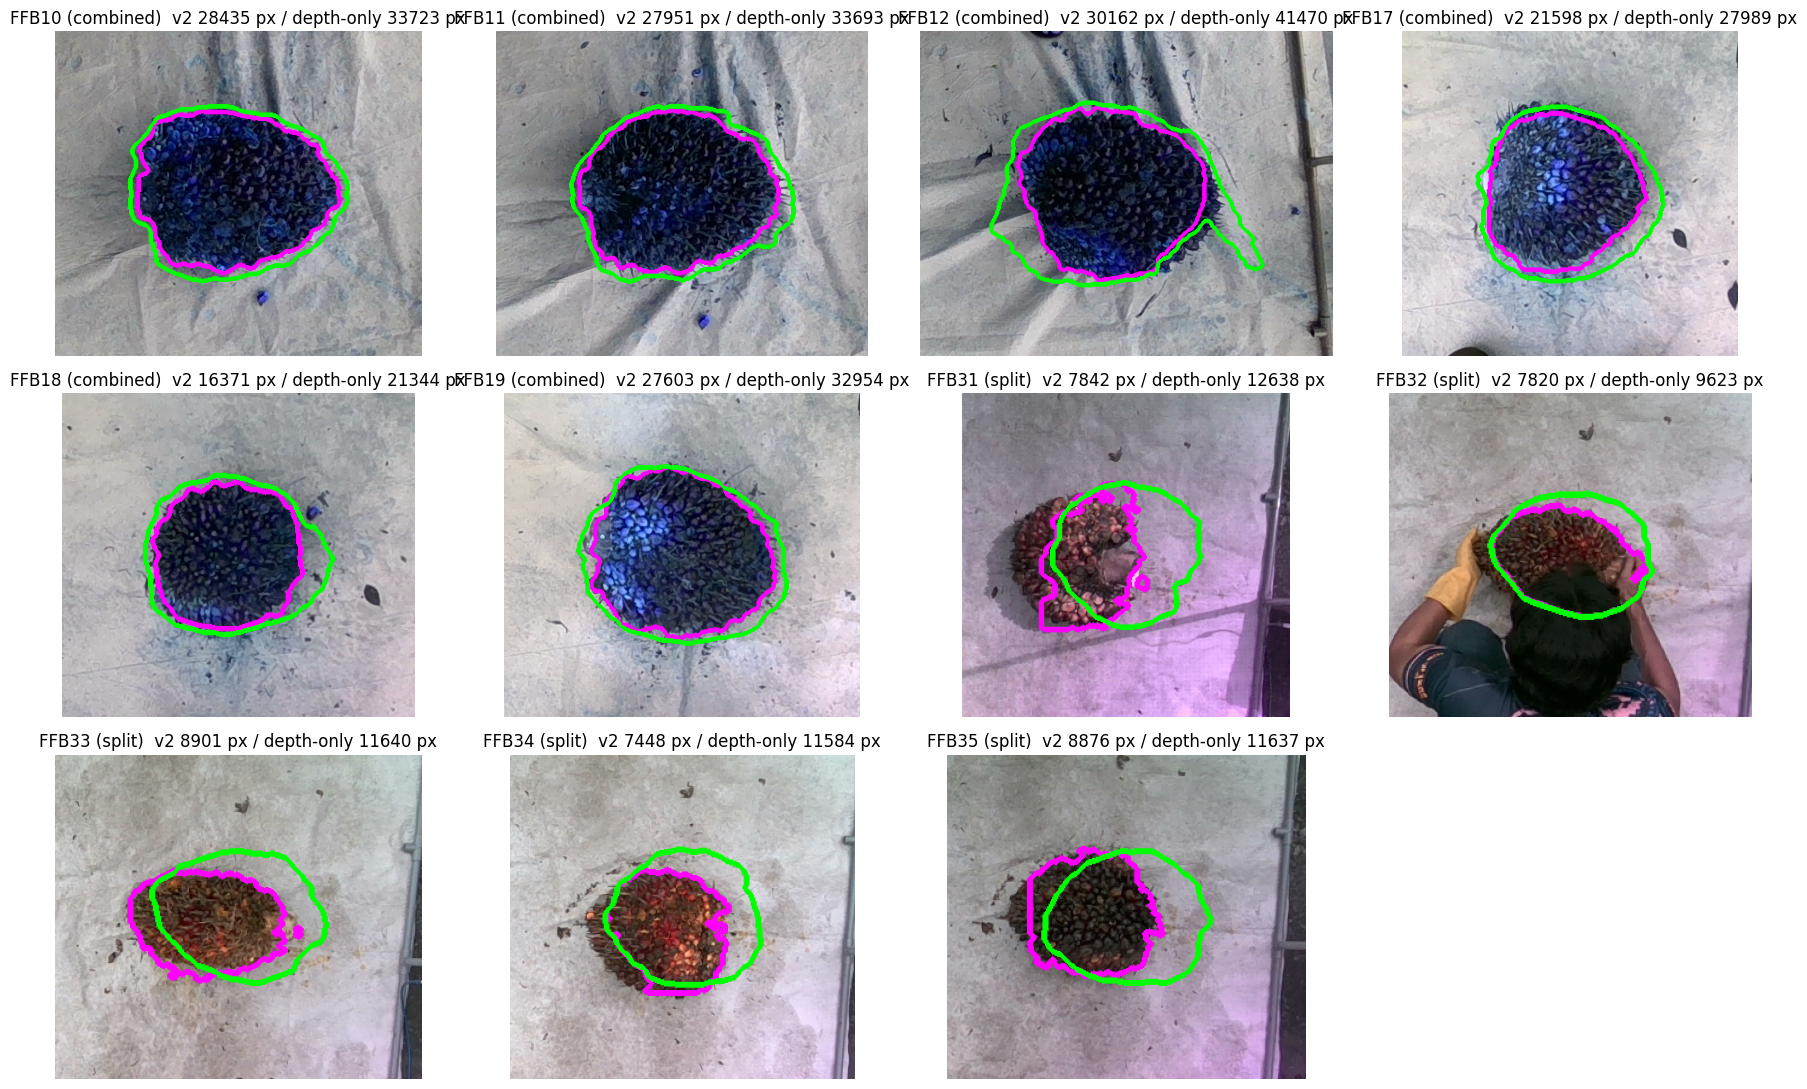

In [4]:
masks = {}
fig, axes = plt.subplots(3, 4, figsize=(18, 11)); axes = axes.ravel()
for ax, (name, s) in zip(axes, scenes.items()):
    fused, rgb, K = s["fused"], s["rgb"], s["K"]
    H, W = fused.shape
    old, *_ = segment.extract_mask(fused, rgb, K.width)
    new, plane = segment.plane_height_mask(fused, K, **PRESPECIFIED)
    masks[name] = (old, new, plane)
    img = cv2.resize(rgb, (W, H)).copy()
    for m, col in ((old, (255, 0, 255)), (new, (0, 255, 0))):
        if m is not None:
            cs, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(img, cs, -1, col, 3)
    ys, xs = np.nonzero(new)
    pad = 80
    ax.imshow(img[max(0, ys.min() - pad):ys.max() + pad, max(0, xs.min() - pad):xs.max() + pad])
    ax.set_title(f"{name} ({s['layout']})  v2 {old.sum()} px / depth-only {new.sum()} px"); ax.axis("off")
axes[-1].axis("off")
plt.tight_layout(); plt.savefig(OUT / "masks.png", dpi=80); plt.show()

## 4. Volumes and the session gap
Tarp-plane volume ÷ displaced volume. With v2's mask the sessions differ by about 1.5×.

In [5]:
rows = []
for name, s in scenes.items():
    old, new, plane = masks[name]
    fused, K = s["fused"], s["K"]
    n, d, _ = volume.fit_plane(volume.tarp_points(fused, old, K))
    v_old = volume.plane_volume(fused, old, K, (n, d))[0]
    v_new = volume.plane_volume(fused, new, K, plane)[0]
    m2, p2 = segment.plane_height_mask(fused, K, **PRESPECIFIED, robust=True)
    rows.append(dict(ffb=name, fusion="notebook", layout=s["layout"], true_L=gt.loc[name, "Actual_Volume_L"],
                     V_plane_v2mask=v_old, V_plane_ph=v_new, V_plane_ph_msac=volume.plane_volume(fused, m2, K, p2)[0],
                     tarp_m=-plane[1] / plane[0][2]))
vol = pd.DataFrame(rows)
v2vol, _ = ex.run_bundles(str(DATA), {"notebook": CFG}, str(CACHE), verbose=False)
vol = vol.merge(v2vol[["ffb", "V_grid"]], on="ffb")
vol.to_csv(OUT / "volumes.csv", index=False)
ratio = vol.set_index("ffb")[["V_plane_v2mask", "V_plane_ph"]].mul(1000).div(vol.set_index("ffb")["true_L"], axis=0)
ratio["layout"] = vol.set_index("ffb")["layout"]
print(ratio.round(2).to_string())
by = ratio.drop(index=ex.EXCLUDED).groupby("layout").median()
print("\nmedian by session:\n", by.round(2)); print("\nsession ratio (1 / 2):", (by.loc["combined"] / by.loc["split"]).round(2).to_dict())

       V_plane_v2mask  V_plane_ph    layout
ffb                                        
FFB10            1.68        1.82  combined
FFB11            2.05        2.23  combined
FFB12            1.66        2.00  combined
FFB17            1.83        2.16  combined
FFB18            1.57        1.88  combined
FFB19            1.52        1.74  combined
FFB31            1.03        1.89     split
FFB32            1.49        1.67     split
FFB33            1.19        1.77     split
FFB34            1.13        1.76     split
FFB35            1.04        1.67     split

median by session:
           V_plane_v2mask  V_plane_ph
layout                              
combined            1.68        2.00
split               1.13        1.76

session ratio (1 / 2): {'V_plane_v2mask': 1.49, 'V_plane_ph': 1.14}


## 5. Held-out comparison against v2
LOO and all 330 4/7 and 7/4 splits; paired bootstrap against v2 (first row per model).

In [6]:
steps = [("v2_grid", "notebook", "V_grid"), ("tarp_plane_v2_mask", "notebook", "V_plane_v2mask"),
         ("depth_only_mask", "notebook", "V_plane_ph"), ("depth_only_mask_msac_lo", "notebook", "V_plane_ph_msac")]
held = ex.heldout_comparison(vol, gt, steps, models=ex.BASE_MODELS[:2])
held.to_csv(OUT / "heldout.csv", index=False)
print(held.pivot_table(index=["model", "step"], columns="scheme", values="mae", aggfunc="first").round(2).to_string())
held[held.step != "v2_grid"][["model", "step", "scheme", "mae", "vs_first_diff", "vs_first_lo", "vs_first_hi", "vs_first_p_not_better"]].round(2)

scheme                                  4/7   7/4   LOO
model         step                                     
global_k      depth_only_mask          1.20  1.14  1.13
              depth_only_mask_msac_lo  1.23  1.16  1.14
              tarp_plane_v2_mask       2.83  2.67  2.65
              v2_grid                  1.66  1.59  1.60
per_session_k depth_only_mask          1.25  1.14  1.09
              depth_only_mask_msac_lo  1.30  1.18  1.13
              tarp_plane_v2_mask       1.90  1.69  1.62
              v2_grid                  1.97  1.65  1.65


,model,step,scheme,mae,vs_first_diff,vs_first_lo,vs_first_hi,vs_first_p_not_better
3,per_session_k,tarp_plane_v2_mask,LOO,1.62,-0.03,-0.83,0.74,0.47
4,per_session_k,tarp_plane_v2_mask,4/7,1.90,-0.07,-0.73,0.57,0.42
5,per_session_k,tarp_plane_v2_mask,7/4,1.69,0.04,-0.72,0.79,0.54
6,per_session_k,depth_only_mask,LOO,1.09,-0.56,-1.22,0.08,0.04
7,per_session_k,depth_only_mask,4/7,1.25,-0.72,-1.34,-0.15,0.01
8,per_session_k,depth_only_mask,7/4,1.14,-0.52,-1.19,0.10,0.05
9,per_session_k,depth_only_mask_msac_lo,LOO,1.13,-0.52,-1.19,0.16,0.07
10,per_session_k,depth_only_mask_msac_lo,4/7,1.30,-0.67,-1.32,-0.08,0.01
11,per_session_k,depth_only_mask_msac_lo,7/4,1.18,-0.47,-1.16,0.18,0.08
15,global_k,tarp_plane_v2_mask,LOO,2.65,1.04,-0.02,2.14,0.97


## 6. Against Aqil's manual workflow, same 10 bunches

In [7]:
a_tab = pd.read_csv(ROOT / "aqil_table_c.csv")
aqil = pd.Series(a_tab["Est_Mass_kg"].to_numpy(), index="FFB" + a_tab["FFB_No"].astype(str))
preds, rows = {}, []
for step, col in (("v2_grid", "V_grid"), ("depth_only_mask", "V_plane_ph")):
    df = ex.step_frame(vol, gt, "notebook", col).drop(index=ex.EXCLUDED)
    for m in ex.BASE_MODELS[:2]:
        p = ev.loo(df, m); preds[(step, m.name)] = p
        act, a = df["mass"], aqil.loc[df.index]
        pb = ev.paired_bootstrap((p - act).abs(), (a - act).abs())
        rows.append(dict(step=step, model=m.name, mae=(p - act).abs().mean(), mape=100 * ((p - act).abs() / act).mean(),
                         aqil_mae=(a - act).abs().mean(), diff_vs_aqil=pb["diff"], lo=pb["lo"], hi=pb["hi"]))
vs_aqil = pd.DataFrame(rows); vs_aqil.to_csv(OUT / "vs_aqil.csv", index=False); vs_aqil.round(2)

,step,model,mae,mape,aqil_mae,diff_vs_aqil,lo,hi
0,v2_grid,per_session_k,1.65,12.35,1.45,0.20,-0.58,0.99
1,v2_grid,global_k,1.60,11.83,1.45,0.15,-0.36,0.68
2,depth_only_mask,per_session_k,1.09,7.48,1.45,-0.36,-1.19,0.45
3,depth_only_mask,global_k,1.13,7.90,1.45,-0.33,-1.22,0.54


## 7. Threshold sensitivity
One-gain and per-session LOO/4-7 MAE over height threshold × tarp band. 2 cm is below the tarp noise floor.

In [8]:
sweep = []
for h_min in (0.02, 0.03, 0.04, 0.05):
    for band in (0.02, 0.03, 0.05):
        r = []
        for name, s in scenes.items():
            m, pl = segment.plane_height_mask(s["fused"], s["K"], h_min=h_min, band=band)
            r.append(dict(ffb=name, fusion="x", layout=s["layout"], V=volume.plane_volume(s["fused"], m, s["K"], pl)[0] if m is not None else np.nan))
        t = ex.heldout_comparison(pd.DataFrame(r), gt, [("s", "x", "V")], models=ex.BASE_MODELS[:2], B=200).set_index(["model", "scheme"])["mae"]
        sweep.append(dict(h_min=h_min, band=band, global_LOO=t["global_k", "LOO"], global_4_7=t["global_k", "4/7"], per_session_LOO=t["per_session_k", "LOO"]))
sweep = pd.DataFrame(sweep); sweep.to_csv(OUT / "sweep.csv", index=False)
sweep.pivot(index="h_min", columns="band", values="global_LOO").round(2)

band,0.02,0.03,0.05
h_min,,,
0.02,5.68,1.23,7.02
0.03,1.04,1.13,1.13
0.04,1.01,1.09,1.11
0.05,1.01,1.09,1.11


## 8. Per-bunch held-out predictions

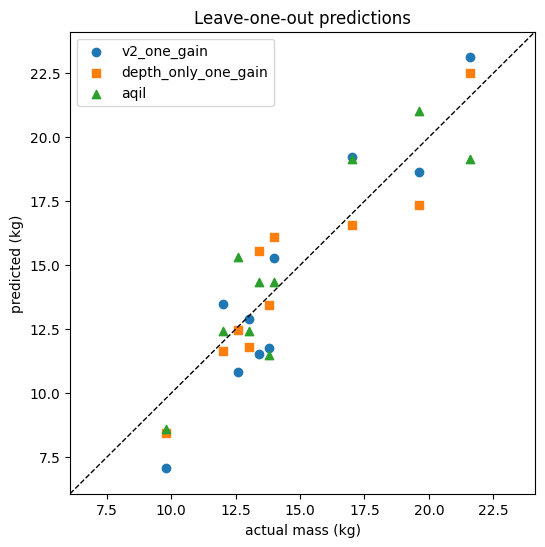

,actual,v2_one_gain,depth_only_one_gain,aqil,session
ffb,,,,,
FFB10,17.0,19.22,16.55,19.13,combined
FFB11,14.0,15.28,16.08,14.34,combined
FFB12,21.6,23.12,22.52,19.13,combined
FFB17,13.4,11.52,15.56,14.34,combined
FFB19,19.6,18.63,17.35,21.04,combined
FFB31,13.8,11.74,13.43,11.48,split
FFB32,9.8,7.07,8.44,8.61,split
FFB33,12.0,13.48,11.64,12.43,split
FFB34,12.6,10.82,12.48,15.30,split


In [9]:
df = ex.step_frame(vol, gt, "notebook", "V_plane_ph").drop(index=ex.EXCLUDED)
per = pd.DataFrame({"actual": df["mass"], "v2_one_gain": preds[("v2_grid", "global_k")],
                    "depth_only_one_gain": preds[("depth_only_mask", "global_k")], "aqil": aqil.loc[df.index], "session": df["group"]})
per.round(2).to_csv(OUT / "per_bunch.csv")
fig, ax = plt.subplots(figsize=(6, 6))
for col, mk in (("v2_one_gain", "o"), ("depth_only_one_gain", "s"), ("aqil", "^")):
    ax.scatter(per["actual"], per[col], marker=mk, label=col)
lim = [per[["actual", "v2_one_gain", "depth_only_one_gain", "aqil"]].min().min() - 1, per[["actual", "v2_one_gain", "depth_only_one_gain", "aqil"]].max().max() + 1]
ax.plot(lim, lim, "k--", lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("actual mass (kg)"); ax.set_ylabel("predicted (kg)"); ax.legend(); ax.set_title("Leave-one-out predictions")
plt.savefig(OUT / "per_bunch.png", dpi=80); plt.show()
per.round(2)

## 9. Summary

In [10]:
g = ex.step_frame(vol, gt, "notebook", "V_plane_ph").drop(index=ex.EXCLUDED)
summary = dict(
    prespecified=PRESPECIFIED,
    heldout_mae={f"{m}:{st}:{sc}": round(float(v), 3) for (m, st, sc), v in held.set_index(["model", "step", "scheme"])["mae"].items()},
    session_ratio={c: round(float(by.loc["combined", c] / by.loc["split", c]), 3) for c in by},
    gains_kg_per_L=dict(global_=round(float(ex.BASE_MODELS[1].fit(g)[0]) / 1000, 3),
                        per_session={k: round(float(v[0]) / 1000, 3) for k, v in ex.BASE_MODELS[0].fit(g).items()}),
    vs_aqil=vs_aqil.round(3).to_dict("records"),
)
(OUT / "summary.json").write_text(json.dumps(summary, indent=2, default=str))
print(json.dumps({k: summary[k] for k in ("session_ratio", "gains_kg_per_L")}, indent=1))
vs_aqil.round(2)

{
 "session_ratio": {
  "V_plane_v2mask": 1.491,
  "V_plane_ph": 1.137
 },
 "gains_kg_per_L": {
  "global_": 0.507,
  "per_session": {
   "combined": 0.496,
   "split": 0.533
  }
 }
}


,step,model,mae,mape,aqil_mae,diff_vs_aqil,lo,hi
0,v2_grid,per_session_k,1.65,12.35,1.45,0.20,-0.58,0.99
1,v2_grid,global_k,1.60,11.83,1.45,0.15,-0.36,0.68
2,depth_only_mask,per_session_k,1.09,7.48,1.45,-0.36,-1.19,0.45
3,depth_only_mask,global_k,1.13,7.90,1.45,-0.33,-1.22,0.54
